# Are Bookmaker Probabilities Well Calibrated?

A model that predicts a football match is "70% likely" to end in a home win should be
right roughly 70% of the time it makes that call. Not 90%, not 50%. That property is
called **calibration**, and it's a different question from **accuracy**. A model can
pick the correct winner most of the time and still be badly calibrated, systematically
over or under confident. Conversely, a well calibrated model doesn't need to be a
particularly sharp predictor to be *honest* about its own uncertainty.

Bookmaker odds are a convenient, free, real world dataset to check this on. They are
probabilistic forecasts issued thousands of times a season, with a clear ground truth:
who actually won. In this notebook I will:

1. convert closing odds into implied probabilities, removing the bookmaker's margin
2. build a **reliability diagram** to visualize calibration and compute the **Brier
   score** to summarize it
3. segment matches by the strength of the favorite (using final league position) to
   check whether calibration holds up as well for lopsided matches involving a weaker
   team as it does for genuine top six favorites. This is a version of the classic
   **favorite-longshot bias** studied in the betting markets literature.

Data: [football-data.co.uk](https://www.football-data.co.uk/englandm.php), free
historical odds, Premier League, 2015/16 to 2024/25 (10 seasons, ~3,800 matches).
Bookmaker: Bet365 closing odds (`B365H/D/A`), chosen for season by season consistency,
since average market odds columns only exist for the more recent seasons.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- house style (see quantitative_finance_playground dataviz conventions) ---
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

TIER_COLORS = {"Strong": "#2a78d6", "Mid": "#eb6834", "Weak": "#1baf7a"}
TIER_LABELS_EN = {"Strong": "Strong favorite", "Mid": "Mid-table favorite", "Weak": "Weak favorite"}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "font.size": 11,
    "axes.grid": True,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Download and pool ten seasons of Premier League odds

In [12]:
# get seasons from 2015 to 2024
# documentation: https://football-data.co.uk/notes.txt
SEASONS = ['1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']
URL = "https://www.football-data.co.uk/mmz4281/{s}/E0.csv"

frames = []
for s in SEASONS:
    df = pd.read_csv(URL.format(s=s))
    df = df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A']].copy()
    df['Season'] = s
    frames.append(df)

matches = pd.concat(frames, ignore_index=True)

# drop nans in odds
matches = matches.dropna(subset=['B365H', 'B365D', 'B365A', 'FTR']).reset_index(drop=True)

print(f"{len(matches)} matches across {len(SEASONS)} seasons")
matches.head()


3800 matches across 10 seasons


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,Season
0,08/08/2015,Bournemouth,Aston Villa,0,1,A,2.00,3.6,4.00,1516
1,08/08/2015,Chelsea,Swansea,2,2,D,1.36,5.0,11.00,1516
2,08/08/2015,Everton,Watford,2,2,D,1.70,3.9,5.50,1516
3,08/08/2015,Leicester,Sunderland,4,2,H,1.95,3.5,4.33,1516
4,08/08/2015,Man United,Tottenham,1,0,H,1.65,4.0,6.00,1516


## 2. From odds to implied probabilities

Odds don't directly give you probabilities: a bookmaker's three prices always add up to
more than 100%, because of the **overround** (their built in margin). The simplest fix,
called "multiplicative" normalization, takes `1/odds` for each outcome and rescales so
the three add up to 1:

$$p_i = \frac{1/\text{odds}_i}{\sum_j 1/\text{odds}_j}$$

This isn't perfect. It spreads the margin evenly across outcomes, while in reality
bookmakers load more margin onto longshots (see Shin's method for a refinement). But
it's the standard, simple starting point, and good enough to see the calibration
patterns we're after.


In [13]:
raw = 1 / matches[['B365H', 'B365D', 'B365A']].values
overround = raw.sum(axis=1) - 1
norm = raw / raw.sum(axis=1, keepdims=True)

# Home, Draw and Away odds
matches['pH'], matches['pD'], matches['pA'] = norm[:, 0], norm[:, 1], norm[:, 2]

print(f"Average overround: {overround.mean():.1%} (the bookmaker's built-in margin)")
matches[['HomeTeam', 'AwayTeam', 'B365H', 'B365D', 'B365A', 'pH', 'pD', 'pA', 'FTR']].head()


Average overround: 4.4% (the bookmaker's built-in margin)


,HomeTeam,AwayTeam,B365H,B365D,B365A,pH,pD,pA,FTR
0,Bournemouth,Aston Villa,2.00,3.6,4.00,0.486486,0.270270,0.243243,A
1,Chelsea,Swansea,1.36,5.0,11.00,0.716519,0.194893,0.088588,D
2,Everton,Watford,1.70,3.9,5.50,0.573070,0.249800,0.177131,D
3,Leicester,Sunderland,1.95,3.5,4.33,0.498135,0.277532,0.224333,H
4,Man United,Tottenham,1.65,4.0,6.00,0.592593,0.244444,0.162963,H


## 3. Reliability diagram and Brier score

To check calibration we need pairs of *(predicted probability, did it happen)*. A match
gives us three such pairs at once, one per outcome, so we reshape from one row per match
to one row per **match outcome**: `(predicted_prob, outcome)`, where `outcome` is 1 if
that specific result occurred and 0 otherwise. This triples the data (3,800 matches to
11,400 observations) and is the standard one-vs-rest way to check calibration of a
multi class forecaster.

We then group observations into probability bins (deciles) and compare, per bin, the
**average predicted probability** against the **observed frequency** of that outcome. A
perfectly calibrated model sits on the diagonal.

The **Brier score** is the mean squared error between predicted probability and outcome,
a single number summarizing calibration quality (among other things). Lower is better:
0 is perfect, 0.25 is what you'd get from guessing 50/50 on a fair coin.


In [14]:
long_rows = []
for _, r in matches.iterrows():
    for outcome_type, col in [('H', 'pH'), ('D', 'pD'), ('A', 'pA')]:
        long_rows.append({
            'predicted_prob': r[col],
            'outcome': int(r['FTR'] == outcome_type),
            'outcome_type': outcome_type,
            'season': r['Season'],
        })
long_df = pd.DataFrame(long_rows)


def brier_score(df: pd.DataFrame, pred_col: str = 'predicted_prob', outcome_col: str = 'outcome') -> float:
    return np.mean((df[pred_col] - df[outcome_col]) ** 2)


def reliability_table(
    df: pd.DataFrame,
    n_bins: int = 10,
    pred_col: str = 'predicted_prob',
    outcome_col: str = 'outcome',
) -> pd.DataFrame:
    bins = np.linspace(0, 1, n_bins + 1)
    tagged = df.assign(bin=pd.cut(df[pred_col], bins, include_lowest=True))
    return tagged.groupby('bin', observed=True).agg(
        mean_predicted=(pred_col, 'mean'),
        empirical_freq=(outcome_col, 'mean'),
        n=(outcome_col, 'size'),
    ).reset_index()


overall_brier = brier_score(long_df)
print(f"Overall Brier score: {overall_brier:.4f}")
for ot, label in [('H', 'Home win'), ('D', 'Draw'), ('A', 'Away win')]:
    sub = long_df[long_df['outcome_type'] == ot]
    print(f"  {label:>9}: Brier = {brier_score(sub):.4f}  (n={len(sub)})")

rel = reliability_table(long_df, n_bins=10)
rel


Overall Brier score: 0.1882
   Home win: Brier = 0.2068  (n=3800)
       Draw: Brier = 0.1759  (n=3800)
   Away win: Brier = 0.1821  (n=3800)


,bin,mean_predicted,empirical_freq,n
0,"(-0.001, 0.1]",0.073247,0.076087,552
1,"(0.1, 0.2]",0.155900,0.160169,1898
2,"(0.2, 0.3]",0.257488,0.251855,4177
3,"(0.3, 0.4]",0.346725,0.339398,1594
4,"(0.4, 0.5]",0.450004,0.438938,1130
5,"(0.5, 0.6]",0.550817,0.574416,813
6,"(0.6, 0.7]",0.648516,0.685393,623
7,"(0.7, 0.8]",0.747534,0.712264,424
8,"(0.8, 0.9]",0.836039,0.893048,187
9,"(0.9, 1.0]",0.912845,1.000000,2


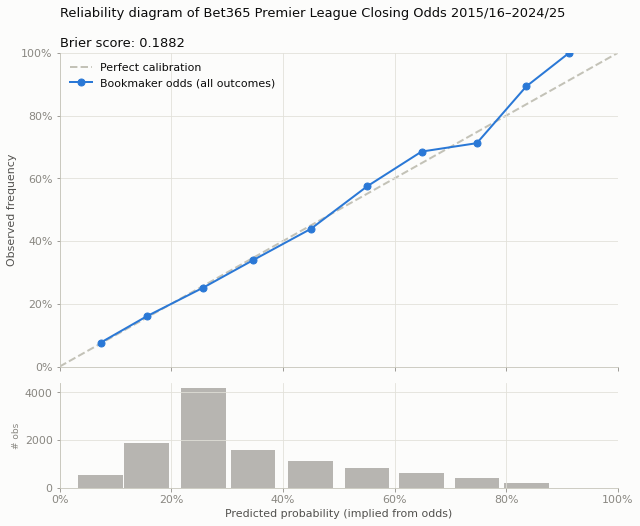

In [15]:
fig, (ax, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, height_ratios=[3, 1], gridspec_kw={'hspace': 0.08}
)

ax.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color=BASELINE, zorder=1, label='Perfect calibration')
ax.plot(rel['mean_predicted'], rel['empirical_freq'], marker='o', markersize=7,
        linewidth=2, color=TIER_COLORS['Strong'], zorder=2, label='Bookmaker odds (all outcomes)')

ax.set_ylabel('Observed frequency')
ax.set_title(f'Reliability diagram of Bet365 Premier League Closing Odds 2015/16–2024/25\n\nBrier score: {overall_brier:.4f}',
             color=INK, fontsize=13, loc='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc='upper left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax_hist.bar(rel['mean_predicted'], rel['n'], width=0.08, color=INK_MUTED, alpha=0.6)
ax_hist.set_ylabel('# obs', color=INK_MUTED, fontsize=9)
ax_hist.set_xlabel('Predicted probability (implied from odds)')
ax_hist.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.savefig('reliability_overall.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()


The curve tracks the diagonal closely at low probabilities (well calibrated longshots),
but drifts *above* it in the 50 to 90% range: when the market says a team has a 55 to
85% chance, that team actually wins more often than that. In other words, the
bookmakers are slightly **under-pricing favorites**, a well documented pattern in
betting markets known as the **favorite-longshot bias**. It's a small effect, a few
points of probability, and well within what you'd expect from margin normalization not
being perfectly uniform across outcomes. But it's consistent and shows up cleanly across
a decade of data.


## 4. Does the bias depend on the strength of the favorite?

Segmenting by *team* would leave too few matches per team to bin reliably, 38 matches a
season. Instead I segment by **the strength of the favorite in each match**, using an
independent, non circular proxy: **final league position that season**. For each season
I rank teams 1 to 20 by points (goal difference as tiebreaker) and split them into three
tiers:

- **Strong**: final position 1 to 6
- **Mid**: final position 7 to 14
- **Weak**: final position 15 to 20

Every match's three outcome rows (H/D/A) get tagged with the tier of whichever team the
market considers the favorite (higher implied probability). So the question becomes: is
the bookmaker equally well calibrated when the favorite is a genuine top club, versus
when "favorite" just means a marginally less bad mid table team?


In [16]:
def season_table(season_matches: pd.DataFrame) -> pd.DataFrame:
    teams = pd.unique(season_matches[['HomeTeam', 'AwayTeam']].values.ravel())
    points = {t: 0 for t in teams}
    goal_diff = {t: 0 for t in teams}
    for _, row in season_matches.iterrows():
        h, a, hg, ag = row['HomeTeam'], row['AwayTeam'], row['FTHG'], row['FTAG']
        goal_diff[h] += hg - ag
        goal_diff[a] += ag - hg
        if row['FTR'] == 'H':
            points[h] += 3
        elif row['FTR'] == 'A':
            points[a] += 3
        else:
            points[h] += 1
            points[a] += 1
    table = pd.DataFrame({'Team': points.keys(), 'Pts': points.values()})
    table['GD'] = table['Team'].map(goal_diff)
    table = table.sort_values(['Pts', 'GD'], ascending=False).reset_index(drop=True)
    table['Rank'] = table.index + 1
    return table


def tier_of(rank: int) -> str:
    if rank <= 6:
        return 'Strong'
    elif rank <= 14:
        return 'Mid'
    return 'Weak'


tier_lookup = {}
for s in SEASONS:
    table = season_table(matches[matches['Season'] == s])
    for _, row in table.iterrows():
        tier_lookup[(s, row['Team'])] = tier_of(row['Rank'])

matches['HomeTier'] = [tier_lookup[(s, t)] for s, t in zip(matches['Season'], matches['HomeTeam'])]
matches['AwayTier'] = [tier_lookup[(s, t)] for s, t in zip(matches['Season'], matches['AwayTeam'])]
matches['FavoriteTier'] = np.where(matches['pH'] >= matches['pA'], matches['HomeTier'], matches['AwayTier'])

long_df['segment'] = np.repeat(matches['FavoriteTier'].values, 3)

print(matches['FavoriteTier'].value_counts().rename('matches where this tier is favorite'))


FavoriteTier
Strong    1906
Mid       1349
Weak       545
Name: matches where this tier is favorite, dtype: int64


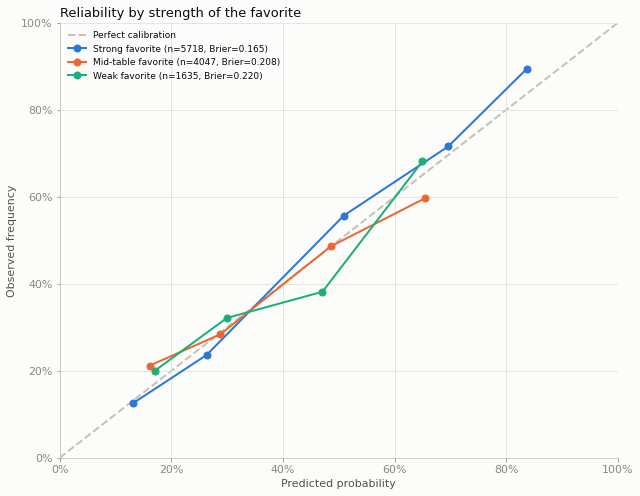

     Strong favorite: Brier = 0.1648
  Mid-table favorite: Brier = 0.2084
       Weak favorite: Brier = 0.2203


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color=BASELINE, zorder=1, label='Perfect calibration')

brier_by_segment = {}
for tier in ['Strong', 'Mid', 'Weak']:
    sub = long_df[long_df['segment'] == tier]
    rel_seg = reliability_table(sub, n_bins=5)
    brier_by_segment[tier] = brier_score(sub)
    ax.plot(rel_seg['mean_predicted'], rel_seg['empirical_freq'], marker='o', markersize=7,
            linewidth=2, color=TIER_COLORS[tier],
            label=f"{TIER_LABELS_EN[tier]} (n={len(sub)}, Brier={brier_by_segment[tier]:.3f})")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Reliability by strength of the favorite', color=INK, fontsize=13, loc='left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.savefig('reliability_by_segment.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

for tier in ['Strong', 'Mid', 'Weak']:
    print(f"{TIER_LABELS_EN[tier]:>20}: Brier = {brier_by_segment[tier]:.4f}")


Two things stand out:

- **Brier score gets worse as the favorite gets weaker** (Strong ~0.165, Mid ~0.208,
  Weak ~0.220). Some of this is simply that matches between two mediocre teams are
  inherently harder to call: the Brier score mixes calibration with how much genuine
  predictive signal exists, and a sharper forecaster earns a lower Brier score even at
  equal calibration. So this gap alone isn't proof of bias.
- The **reliability curves**, which isolate calibration from sharpness, tell the more
  precise story. The "Strong" curve sits closest to the diagonal at low to mid
  probabilities, but gets pulled *above* it exactly where the classic favorite-longshot
  bias predicts: in the region where the market is most confident (0.6 to 0.9), true
  top six favorites win noticeably more than their quoted probability. That gap shrinks,
  and gets noisier on far fewer observations, once "favorite" only means a mid table or
  bottom half side barely ahead of an even weaker opponent.

Put together: bookmakers are good, but not perfectly calibrated, and the direction of
their error is systematic. They're most likely to underestimate a genuinely strong
favorite, less so a favorite that's only relatively stronger than a weak opponent.


## 5. Caveats

- **Sample size drops fast per segment**: "Weak" has only about 1,600 of the 11,400
  observations, and the top probability bin is thin, single digit percent bins can be
  just a few dozen matches. Read the tail of each curve as suggestive, not conclusive.
- **Brier score conflates calibration and sharpness** (see above). It's a useful
  headline number, but the reliability curve is the more honest diagnostic when
  comparing segments with different inherent predictability.
- **Multiplicative de-vigging is the simplest overround removal method**, not the most
  accurate one. Shin's method (which assumes insider or informed money concentrates on
  favorites) typically produces slightly different, usually more favorite leaning,
  implied probabilities, and would be a natural next step.
- Season **2020/21** was played behind closed doors, which is known to have reduced
  home advantage. It's included here for sample size, but if you want to isolate that
  effect, drop it and compare.

## 6. Export a clean dataset for the calibration checker webapp

The same `(predicted_prob, outcome, segment)` shape generalizes to *any* probabilistic
forecaster, not just bookmakers: a churn model, a weather forecast, a medical risk
score. That's exactly the input format for the companion tool:
**[Calibration Checker](../../apps/calibration-checker/index.html)**, a small reusable
webapp. Upload any CSV in this shape and get a reliability diagram and Brier score,
optionally split by segment, in your browser.


In [18]:
export_cols = long_df[['predicted_prob', 'outcome', 'segment', 'outcome_type', 'season']].copy()
export_cols.to_csv('football_calibration_demo.csv', index=False)
print(f"Exported {len(export_cols)} rows to football_calibration_demo.csv")
export_cols.head()


Exported 11400 rows to football_calibration_demo.csv


,predicted_prob,outcome,segment,outcome_type,season
0,0.486486,0,Weak,H,1516
1,0.270270,0,Weak,D,1516
2,0.243243,1,Weak,A,1516
3,0.716519,0,Mid,H,1516
4,0.194893,1,Mid,D,1516
